# Proyecto de Estadistica: factores asociados a ingresos por ventas

Este proyecto analiza un dataset de ventas y marketing para responder, con lenguaje de asociacion, la pregunta principal: **Que factores de marketing, comportamiento del cliente, engagement digital y contexto comercial estan mas asociados con los ingresos por ventas?**

La variable objetivo es `sales_revenue_usd`. Las variables explicativas se organizan en cuatro bloques empresariales: marketing, cliente, digital/engagement y contexto comercial. El objetivo estadistico es explorar los datos, describir sus patrones principales y cuantificar asociaciones mediante una regresion lineal multiple, reservando un conjunto de test para evaluar R2, MAE y RMSE.

## 1. Librerias y configuracion

Se importan librerias estandar para analisis descriptivo, visualizacion, regresion lineal multiple, diagnostico y evaluacion predictiva. Se fija `random_state=42` para asegurar reproducibilidad.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from IPython.display import display, Markdown
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_white
from statsmodels.tools.sm_exceptions import SingularMatrixWarning

warnings.filterwarnings("ignore", category=SingularMatrixWarning)

RANDOM_STATE = 42
TARGET = "sales_revenue_usd"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.options.display.float_format = "{:,.2f}".format

def usd(x):
    return f"{x:,.2f} USD"

## 2. Carga e inspeccion inicial

Primero se revisa la estructura basica del dataset: dimensiones, columnas, tipos de datos, primeras observaciones, fechas, duplicados y valores nulos. La variable `date` se convierte a fecha, pero el proyecto no se trata como serie temporal.

In [2]:
df = pd.read_csv("marketing_sales_dataset.csv")
df["date"] = pd.to_datetime(df["date"])

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
print(f"Fecha minima: {df['date'].min().date()}")
print(f"Fecha maxima: {df['date'].max().date()}")
print(f"Duplicados exactos: {df.duplicated().sum():,}")

display(pd.DataFrame({"columna": df.columns}))
display(df.dtypes.rename("tipo").reset_index().rename(columns={"index": "variable"}))
display(df.head())

missing_table = (
    pd.DataFrame({"n_nulos": df.isna().sum(), "pct_nulos": df.isna().mean() * 100})
    .sort_values("pct_nulos", ascending=False)
)
display(missing_table[missing_table["n_nulos"] > 0])

missing_nonzero = missing_table[missing_table["n_nulos"] > 0]
missing_text = ", ".join([f"`{idx}` ({row.n_nulos:,.0f}; {row.pct_nulos:.2f}%)" for idx, row in missing_nonzero.iterrows()])
display(Markdown(
    f"El dataset contiene **{df.shape[0]:,} observaciones** y **{df.shape[1]} variables**. "
    f"El periodo observado va de **{df['date'].min().date()}** a **{df['date'].max().date()}**. "
    f"No se utiliza `date` como predictor principal porque el enfoque es transversal. "
    f"Los nulos se concentran en {missing_text}; se conservaran en la descriptiva y se imputaran con mediana solo al preparar la regresion."
))

Filas: 60,000
Columnas: 23
Fecha minima: 2020-01-01
Fecha maxima: 2023-12-31
Duplicados exactos: 0


,columna
0,id
1,date
2,region
3,sales_channel
4,product_category
5,customer_segment
6,season
7,marketing_budget_usd
8,ad_spend_online_usd
9,ad_spend_offline_usd


,variable,tipo
0,id,int64
1,date,datetime64[us]
2,region,str
3,sales_channel,str
4,product_category,str
5,customer_segment,str
6,season,str
7,marketing_budget_usd,float64
8,ad_spend_online_usd,float64
9,ad_spend_offline_usd,float64


,id,date,region,sales_channel,product_category,customer_segment,season,marketing_budget_usd,ad_spend_online_usd,ad_spend_offline_usd,...,customer_age,customer_satisfaction_score,competitor_price_index,website_traffic,conversion_rate,email_open_rate,social_media_followers,days_since_last_purchase,num_previous_purchases,sales_revenue_usd
0,1,2020-11-12,Riyadh,Retail Store,Cosmetics,Regular,Q4,"1,664.51",952.30,326.97,...,42,4.50,0.76,1952,0.12,0.04,2034,25.00,6,"3,772.90"
1,2,2022-07-05,Dubai,Online,Cosmetics,New,Q3,"2,452.29","1,014.25",414.76,...,24,3.70,1.07,3185,0.04,0.32,2058,187.00,7,"2,091.36"
2,3,2020-11-11,Riyadh,Online,Electronics,Regular,Q4,"1,026.13",328.30,242.72,...,32,2.00,1.18,1304,0.15,0.30,417,139.00,3,"6,201.11"
3,4,2022-10-01,Cairo,Online,Electronics,Regular,Q4,"1,102.86",628.30,204.58,...,62,2.60,0.86,1609,0.05,0.11,20618,308.00,6,"4,911.38"
4,5,2023-12-12,Cairo,Retail Store,Food & Beverage,Corporate,Q4,"2,517.55",777.24,817.88,...,23,3.00,1.01,366639,0.17,0.18,57116,97.00,6,"7,705.73"


,n_nulos,pct_nulos
customer_satisfaction_score,1844,3.07
days_since_last_purchase,1836,3.06
discount_percentage,1808,3.01
email_open_rate,1790,2.98


El dataset contiene **60,000 observaciones** y **23 variables**. El periodo observado va de **2020-01-01** a **2023-12-31**. No se utiliza `date` como predictor principal porque el enfoque es transversal. Los nulos se concentran en `customer_satisfaction_score` (1,844; 3.07%), `days_since_last_purchase` (1,836; 3.06%), `discount_percentage` (1,808; 3.01%), `email_open_rate` (1,790; 2.98%); se conservaran en la descriptiva y se imputaran con mediana solo al preparar la regresion.

## 3. Clasificacion de variables

Esta tabla define la variable objetivo, las variables explicativas y los bloques empresariales. `id` queda fuera por ser identificador y `date` solo describe el periodo observado.

In [3]:
marketing_vars = ["marketing_budget_usd", "ad_spend_online_usd", "ad_spend_offline_usd", "num_promotions", "discount_percentage"]
cliente_vars = ["customer_segment", "customer_age", "customer_satisfaction_score", "days_since_last_purchase", "num_previous_purchases"]
digital_vars = ["website_traffic", "conversion_rate", "email_open_rate", "social_media_followers"]
contexto_vars = ["region", "sales_channel", "product_category", "season", "num_sales_representatives", "competitor_price_index"]
categorical_cols = ["region", "sales_channel", "product_category", "customer_segment", "season"]

variable_info = pd.DataFrame([
    ("id", "identificador", "identificacion", "excluida"),
    ("date", "fecha", "contexto temporal", "solo inspeccion"),
    (TARGET, "cuantitativa continua", "resultado", "variable objetivo"),
    ("marketing_budget_usd", "cuantitativa continua", "marketing", "explicativa candidata"),
    ("ad_spend_online_usd", "cuantitativa continua", "marketing", "explicativa exploratoria"),
    ("ad_spend_offline_usd", "cuantitativa continua", "marketing", "explicativa exploratoria"),
    ("num_promotions", "cuantitativa discreta", "marketing", "explicativa candidata"),
    ("discount_percentage", "cuantitativa continua", "marketing", "explicativa candidata"),
    ("customer_segment", "cualitativa nominal", "cliente", "explicativa candidata"),
    ("customer_age", "cuantitativa discreta", "cliente", "explicativa candidata"),
    ("customer_satisfaction_score", "cuantitativa ordinal", "cliente", "explicativa candidata"),
    ("days_since_last_purchase", "cuantitativa continua", "cliente", "explicativa candidata"),
    ("num_previous_purchases", "cuantitativa discreta", "cliente", "explicativa candidata"),
    ("website_traffic", "cuantitativa discreta", "digital / engagement", "explicativa candidata"),
    ("conversion_rate", "cuantitativa continua", "digital / engagement", "explicativa candidata"),
    ("email_open_rate", "cuantitativa continua", "digital / engagement", "explicativa candidata"),
    ("social_media_followers", "cuantitativa discreta", "digital / engagement", "explicativa candidata"),
    ("region", "cualitativa nominal", "contexto comercial", "explicativa candidata"),
    ("sales_channel", "cualitativa nominal", "contexto comercial", "explicativa candidata"),
    ("product_category", "cualitativa nominal", "contexto comercial", "explicativa candidata"),
    ("season", "cualitativa ordinal", "contexto comercial", "explicativa candidata"),
    ("num_sales_representatives", "cuantitativa discreta", "contexto comercial", "explicativa candidata"),
    ("competitor_price_index", "cuantitativa continua", "contexto comercial", "explicativa candidata"),
], columns=["variable", "tipo_estadistico", "bloque", "papel"])
display(variable_info)

,variable,tipo_estadistico,bloque,papel
0,id,identificador,identificacion,excluida
1,date,fecha,contexto temporal,solo inspeccion
2,sales_revenue_usd,cuantitativa continua,resultado,variable objetivo
3,marketing_budget_usd,cuantitativa continua,marketing,explicativa candidata
4,ad_spend_online_usd,cuantitativa continua,marketing,explicativa exploratoria
5,ad_spend_offline_usd,cuantitativa continua,marketing,explicativa exploratoria
6,num_promotions,cuantitativa discreta,marketing,explicativa candidata
7,discount_percentage,cuantitativa continua,marketing,explicativa candidata
8,customer_segment,cualitativa nominal,cliente,explicativa candidata
9,customer_age,cuantitativa discreta,cliente,explicativa candidata


## 4. Calidad de datos

Se buscan duplicados, nulos y valores imposibles o fuera de rango. No se eliminan datos automaticamente: primero se documenta el problema y se decide si afecta al analisis.

In [4]:
checks = [
    ("duplicados_exactos", df.duplicated().sum()),
    ("conversion_rate_fuera_0_1", ((df["conversion_rate"] < 0) | (df["conversion_rate"] > 1)).sum()),
    ("email_open_rate_fuera_0_1", ((df["email_open_rate"] < 0) | (df["email_open_rate"] > 1)).sum()),
    ("discount_percentage_negativo_o_mayor_100", ((df["discount_percentage"] < 0) | (df["discount_percentage"] > 100)).sum()),
    ("customer_age_negativa", (df["customer_age"] < 0).sum()),
    ("sales_revenue_usd_negativo", (df[TARGET] < 0).sum()),
    ("days_since_last_purchase_negativo", (df["days_since_last_purchase"] < 0).sum()),
]
quality_table = pd.DataFrame(checks, columns=["revision", "n_casos"])
display(quality_table)
print(f"Rango observado de customer_satisfaction_score: {df['customer_satisfaction_score'].min():.2f} a {df['customer_satisfaction_score'].max():.2f}")

if quality_table[quality_table["n_casos"] > 0].empty:
    display(Markdown("No aparecen duplicados exactos ni valores imposibles en las reglas revisadas. La decision es conservar las observaciones. Los nulos numericos se mantendran en la descriptiva y, para la regresion, se imputaran mediante mediana porque es resistente a outliers."))
else:
    display(Markdown("Hay incidencias de calidad que deben revisarse antes de eliminar datos. En esta notebook no se eliminan automaticamente porque un valor extremo o faltante no equivale necesariamente a error."))

,revision,n_casos
0,duplicados_exactos,0
1,conversion_rate_fuera_0_1,0
2,email_open_rate_fuera_0_1,0
3,discount_percentage_negativo_o_mayor_100,0
4,customer_age_negativa,0
5,sales_revenue_usd_negativo,0
6,days_since_last_purchase_negativo,0


Rango observado de customer_satisfaction_score: 2.00 a 5.00


No aparecen duplicados exactos ni valores imposibles en las reglas revisadas. La decision es conservar las observaciones. Los nulos numericos se mantendran en la descriptiva y, para la regresion, se imputaran mediante mediana porque es resistente a outliers.

## 5. Estadistica descriptiva numerica

Se calculan medidas de tendencia central, dispersion y distribucion para las variables numericas relevantes. Esta tabla sirve como herramienta de exploracion; en el informe final solo convendra incluir los indicadores mas importantes.

In [5]:
numeric_cols = [c for c in df.select_dtypes(include="number").columns if c != "id"]
desc = pd.DataFrame({
    "count": df[numeric_cols].count(),
    "media": df[numeric_cols].mean(),
    "mediana": df[numeric_cols].median(),
    "desv_tipica": df[numeric_cols].std(),
    "min": df[numeric_cols].min(),
    "Q1": df[numeric_cols].quantile(0.25),
    "Q3": df[numeric_cols].quantile(0.75),
    "max": df[numeric_cols].max(),
    "rango": df[numeric_cols].max() - df[numeric_cols].min(),
    "IQR": df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25),
    "asimetria": df[numeric_cols].skew(),
    "curtosis": df[numeric_cols].kurtosis(),
})
display(desc.round(3))
most_skewed = desc["asimetria"].abs().sort_values(ascending=False).head(3).index.tolist()
display(Markdown(
    "La descriptiva combina tendencia central, dispersion y forma de la distribucion. "
    f"Las variables con mayor asimetria absoluta son {', '.join([f'`{v}`' for v in most_skewed])}. "
    "Esto importa porque la media puede estar mas influida por valores extremos que la mediana."
))

,count,media,mediana,desv_tipica,min,Q1,Q3,max,rango,IQR,asimetria,curtosis
marketing_budget_usd,60000,"10,031.91","4,922.12","17,300.26",500.00,"2,183.57","11,040.09","500,000.00","499,500.00","8,856.52",7.46,102.94
ad_spend_online_usd,60000,"4,018.44","1,876.36","7,308.81",100.14,816.83,"4,336.85","235,211.83","235,111.69","3,520.02",8.10,126.19
ad_spend_offline_usd,60000,"2,508.81","1,152.39","4,668.24",50.03,486.86,"2,676.80","138,327.25","138,277.22","2,189.94",8.25,127.89
num_promotions,60000,4.49,4.00,2.87,0.00,2.00,7.00,9.00,9.00,5.00,0.01,-1.22
discount_percentage,58192,20.05,20.00,11.51,0.00,10.10,30.00,40.00,40.00,19.90,-0.00,-1.19
num_sales_representatives,60000,24.93,25.00,14.18,1.00,13.00,37.00,49.00,48.00,24.00,0.01,-1.21
customer_age,60000,45.80,46.00,16.48,18.00,31.00,60.00,74.00,56.00,29.00,0.01,-1.21
customer_satisfaction_score,58156,3.50,3.50,0.87,2.00,2.70,4.20,5.00,3.00,1.50,0.01,-1.19
competitor_price_index,60000,1.00,1.00,0.17,0.70,0.85,1.15,1.30,0.60,0.30,0.00,-1.19
website_traffic,60000,"24,425.58","8,065.00","63,866.42",100.00,"2,961.00","22,057.00","2,000,000.00","1,999,900.00","19,096.00",11.51,222.71


La descriptiva combina tendencia central, dispersion y forma de la distribucion. Las variables con mayor asimetria absoluta son `social_media_followers`, `website_traffic`, `ad_spend_offline_usd`. Esto importa porque la media puede estar mas influida por valores extremos que la mediana.

## 6. Estadistica descriptiva categorica

Se resumen frecuencias, porcentajes y categoria modal para las variables cualitativas principales. La seccion se mantiene compacta para no ocupar espacio innecesario en el informe.

In [6]:
categorical_summary = []
category_tables = {}
for col in categorical_cols:
    table = df[col].value_counts(dropna=False).rename_axis(col).reset_index(name="frecuencia")
    table["porcentaje"] = table["frecuencia"] / len(df) * 100
    category_tables[col] = table
    modal = table.iloc[0]
    categorical_summary.append({
        "variable": col,
        "n_categorias": df[col].nunique(dropna=False),
        "categoria_mas_frecuente": modal[col],
        "frecuencia": modal["frecuencia"],
        "porcentaje": modal["porcentaje"],
    })
display(pd.DataFrame(categorical_summary).round(2))
for col, table in category_tables.items():
    print(f"\n{col}")
    display(table.round(2))

,variable,n_categorias,categoria_mas_frecuente,frecuencia,porcentaje
0,region,7,Cairo,14984,24.97
1,sales_channel,5,Online,18010,30.02
2,product_category,5,Food & Beverage,15023,25.04
3,customer_segment,4,Regular,23906,39.84
4,season,4,Q3,15124,25.21



region


,region,frecuencia,porcentaje
0,Cairo,14984,24.97
1,Riyadh,11971,19.95
2,Dubai,10890,18.15
3,Alexandria,9027,15.04
4,Kuwait,4739,7.90
5,Amman,4206,7.01
6,Casablanca,4183,6.97



sales_channel


,sales_channel,frecuencia,porcentaje
0,Online,18010,30.02
1,Retail Store,14954,24.92
2,Wholesale,11987,19.98
3,Direct Sales,9209,15.35
4,Social Media,5840,9.73


...

,product_category,frecuencia,porcentaje
0,Food & Beverage,15023,25.04
1,Electronics,13118,21.86
2,Clothing,12016,20.03
3,Home Appliances,10775,17.96
4,Cosmetics,9068,15.11



customer_segment


,customer_segment,frecuencia,porcentaje
0,Regular,23906,39.84
1,New,18011,30.02
2,Corporate,9113,15.19
3,VIP,8970,14.95



season


,season,frecuencia,porcentaje
0,Q3,15124,25.21
1,Q4,15024,25.04
2,Q2,14954,24.92
3,Q1,14898,24.83


## 7. Variable objetivo: `sales_revenue_usd`

Esta es la seccion central de la descriptiva. Se analiza la distribucion de ingresos mediante estadisticos, histograma y boxplot. Todavia no se eliminan outliers.

,resultado
media,"5,911.12"
mediana,"4,340.05"
desv_tipica,"5,842.47"
min,481.08
Q1,"2,744.18"
Q3,"7,091.63"
max,"190,377.35"
asimetria,6.63
curtosis,105.03


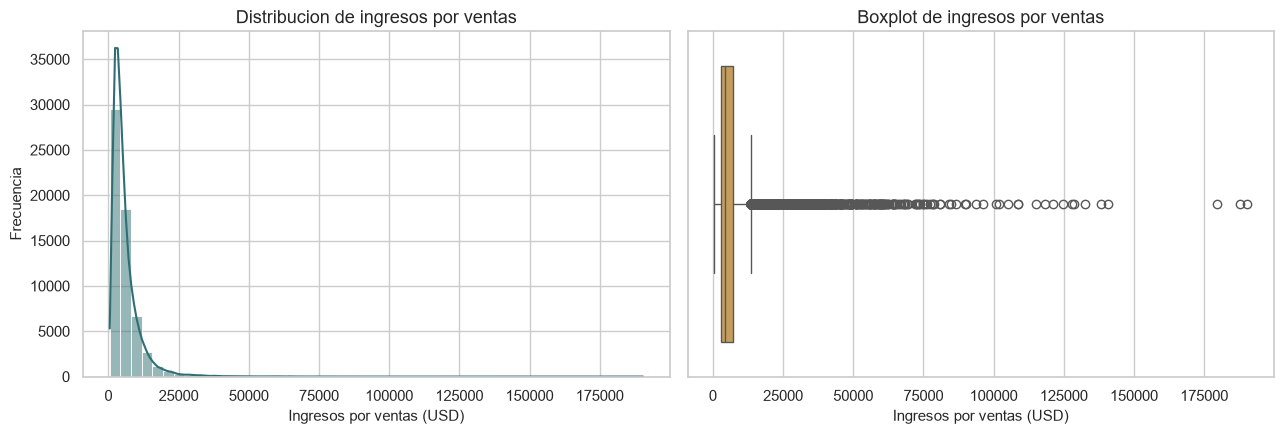

Los ingresos medios son **5,911.12 USD** y la mediana es **4,340.05 USD**. La media supera a la mediana, lo que junto con una asimetria de **6.63** indica cola derecha. El maximo observado es **190,377.35 USD**. Estos valores extremos pueden ser operaciones comercialmente posibles, por lo que no se eliminan antes de analizarlos.

In [7]:
revenue_stats = pd.Series({
    "media": df[TARGET].mean(),
    "mediana": df[TARGET].median(),
    "desv_tipica": df[TARGET].std(),
    "min": df[TARGET].min(),
    "Q1": df[TARGET].quantile(0.25),
    "Q3": df[TARGET].quantile(0.75),
    "max": df[TARGET].max(),
    "asimetria": df[TARGET].skew(),
    "curtosis": df[TARGET].kurtosis(),
})
display(revenue_stats.to_frame("resultado").round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df[TARGET], bins=50, kde=True, ax=axes[0], color="#2F6F73")
axes[0].set_title("Distribucion de ingresos por ventas")
axes[0].set_xlabel("Ingresos por ventas (USD)")
axes[0].set_ylabel("Frecuencia")
sns.boxplot(x=df[TARGET], ax=axes[1], color="#D8A24A")
axes[1].set_title("Boxplot de ingresos por ventas")
axes[1].set_xlabel("Ingresos por ventas (USD)")
plt.tight_layout()
plt.show()

display(Markdown(
    f"Los ingresos medios son **{usd(revenue_stats['media'])}** y la mediana es **{usd(revenue_stats['mediana'])}**. "
    f"La media supera a la mediana, lo que junto con una asimetria de **{revenue_stats['asimetria']:.2f}** indica cola derecha. "
    f"El maximo observado es **{usd(revenue_stats['max'])}**. Estos valores extremos pueden ser operaciones comercialmente posibles, por lo que no se eliminan antes de analizarlos."
))

## 8. Outliers mediante IQR

Se aplica el metodo IQR visto en clase. Un outlier no equivale automaticamente a error: puede ser una observacion real e informativa. Por eso se documenta y se conserva inicialmente.

In [8]:
def iqr_outliers(series, multiplier=1.5):
    clean = series.dropna()
    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    mask = (series < lower) | (series > upper)
    return {
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "limite_inferior": lower, "limite_superior": upper,
        "n_outliers": int(mask.sum()), "pct_outliers": mask.mean() * 100,
    }

outlier_vars = [TARGET, "marketing_budget_usd", "ad_spend_online_usd", "ad_spend_offline_usd", "website_traffic", "social_media_followers"]
outlier_table = pd.DataFrame({v: iqr_outliers(df[v]) for v in outlier_vars}).T
outlier_table["n_outliers"] = outlier_table["n_outliers"].astype(int)
display(outlier_table.round(3))

rev_out = outlier_table.loc[TARGET]
display(Markdown(
    f"El metodo IQR identifica **{rev_out['n_outliers']:,.0f}** outliers en `sales_revenue_usd`, equivalentes al **{rev_out['pct_outliers']:.2f}%** de la muestra. "
    "La decision inicial es conservarlos, porque en ventas los importes altos pueden representar clientes, canales o categorias relevantes, no necesariamente errores de captura."
))

,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,pct_outliers
sales_revenue_usd,"2,744.18","7,091.63","4,347.45","-3,777.00","13,612.81",3816,6.36
marketing_budget_usd,"2,183.57","11,040.09","8,856.52","-11,101.22","24,324.87",5459,9.10
ad_spend_online_usd,816.83,"4,336.85","3,520.02","-4,463.20","9,616.88",5563,9.27
ad_spend_offline_usd,486.86,"2,676.80","2,189.94","-2,798.05","5,961.71",5611,9.35
website_traffic,"2,961.00","22,057.00","19,096.00","-25,683.00","50,701.00",6504,10.84
social_media_followers,771.00,"11,386.75","10,615.75","-15,152.62","27,310.38",8068,13.45


El metodo IQR identifica **3,816** outliers en `sales_revenue_usd`, equivalentes al **6.36%** de la muestra. La decision inicial es conservarlos, porque en ventas los importes altos pueden representar clientes, canales o categorias relevantes, no necesariamente errores de captura.

## 9. Comparaciones por grupos

Se compara `sales_revenue_usd` por segmento, canal, categoria, region y temporada. Estas diferencias son descriptivas: todavia no controlan simultaneamente el resto de variables.


customer_segment


,count,mean,median
customer_segment,,,
Corporate,9113,"10,675.99","8,801.11"
VIP,8970,"8,844.19","7,203.50"
Regular,23906,"4,869.94","4,014.76"
New,18011,"3,421.45","2,792.22"



sales_channel


,count,mean,median
sales_channel,,,
Wholesale,11987,"6,684.04","4,984.74"
Online,18010,"6,110.05","4,499.17"
Social Media,5840,"5,739.94","4,263.08"
Retail Store,14954,"5,626.50","4,132.64"
Direct Sales,9209,"5,086.74","3,726.88"



product_category


,count,mean,median
product_category,,,
Electronics,13118,"7,972.07","6,080.41"
Home Appliances,10775,"6,881.09","5,226.42"
Cosmetics,9068,"5,201.24","3,761.41"
Clothing,12016,"4,907.28","3,499.33"
Food & Beverage,15023,"4,647.21","3,209.60"



region


,count,mean,median
region,,,
Amman,4206,"6,013.88","4,391.05"
Casablanca,4183,"5,948.75","4,357.92"
Kuwait,4739,"5,941.96","4,339.49"
Cairo,14984,"5,932.85","4,331.00"
Alexandria,9027,"5,930.62","4,399.29"
Dubai,10890,"5,878.58","4,326.03"
Riyadh,11971,"5,837.35","4,314.43"



season


,count,mean,median
season,,,
Q4,15024,"7,548.73","5,619.44"
Q3,15124,"5,891.21","4,380.80"
Q2,14954,"5,446.46","4,101.80"
Q1,14898,"4,746.28","3,484.30"


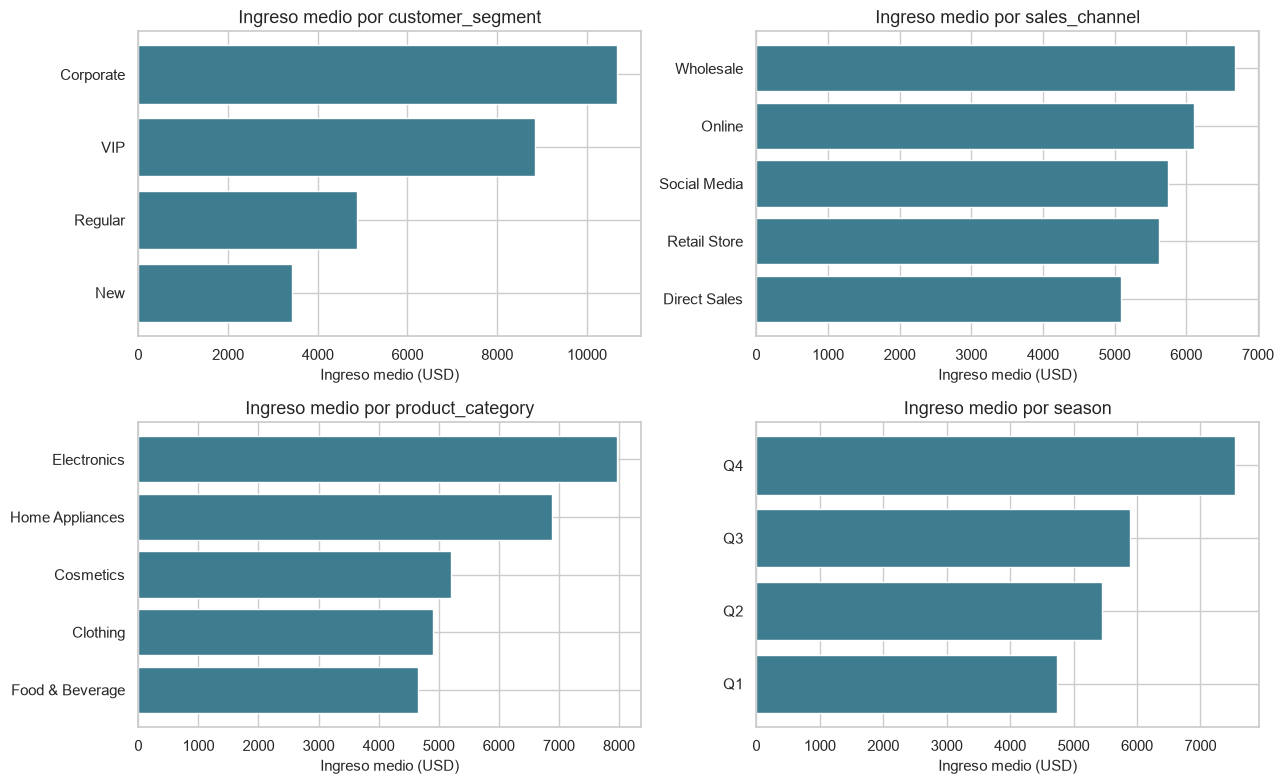

En `customer_segment`, el mayor ingreso medio aparece en **Corporate** (10,675.99 USD) y el menor en **New** (3,421.45 USD).

En `sales_channel`, el mayor ingreso medio aparece en **Wholesale** (6,684.04 USD) y el menor en **Direct Sales** (5,086.74 USD).

En `product_category`, el mayor ingreso medio aparece en **Electronics** (7,972.07 USD) y el menor en **Food & Beverage** (4,647.21 USD).

En `region`, el mayor ingreso medio aparece en **Amman** (6,013.88 USD) y el menor en **Riyadh** (5,837.35 USD).

En `season`, el mayor ingreso medio aparece en **Q4** (7,548.73 USD) y el menor en **Q1** (4,746.28 USD).

In [9]:
def revenue_by_group(data, group_col):
    return data.groupby(group_col)[TARGET].agg(count="count", mean="mean", median="median").sort_values("mean", ascending=False)

group_cols = ["customer_segment", "sales_channel", "product_category", "region", "season"]
group_tables = {col: revenue_by_group(df, col) for col in group_cols}
for col, table in group_tables.items():
    print(f"\n{col}")
    display(table.round(2))

plot_group_cols = ["customer_segment", "sales_channel", "product_category", "season"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()
for ax, col in zip(axes, plot_group_cols):
    table = group_tables[col].sort_values("mean", ascending=True)
    ax.barh(table.index.astype(str), table["mean"], color="#3E7C8F")
    ax.set_title(f"Ingreso medio por {col}")
    ax.set_xlabel("Ingreso medio (USD)")
plt.tight_layout()
plt.show()

interpretations = []
for col in group_cols:
    table = group_tables[col]
    hi, lo = table.iloc[0], table.iloc[-1]
    interpretations.append(f"En `{col}`, el mayor ingreso medio aparece en **{table.index[0]}** ({usd(hi['mean'])}) y el menor en **{table.index[-1]}** ({usd(lo['mean'])}).")
display(Markdown("\n\n".join(interpretations)))

## 10. Relaciones numericas

Se calculan correlaciones entre variables numericas y la variable objetivo, ordenadas por valor absoluto. Luego se visualizan relaciones con sentido empresarial. Correlacion no implica causalidad.

,correlacion_con_sales_revenue,abs_correlacion
marketing_budget_usd,0.73,0.73
ad_spend_online_usd,0.70,0.70
ad_spend_offline_usd,0.68,0.68
num_previous_purchases,0.05,0.05
customer_satisfaction_score,0.04,0.04
conversion_rate,0.04,0.04
num_promotions,0.04,0.04
discount_percentage,-0.02,0.02
website_traffic,0.02,0.02
competitor_price_index,-0.02,0.02


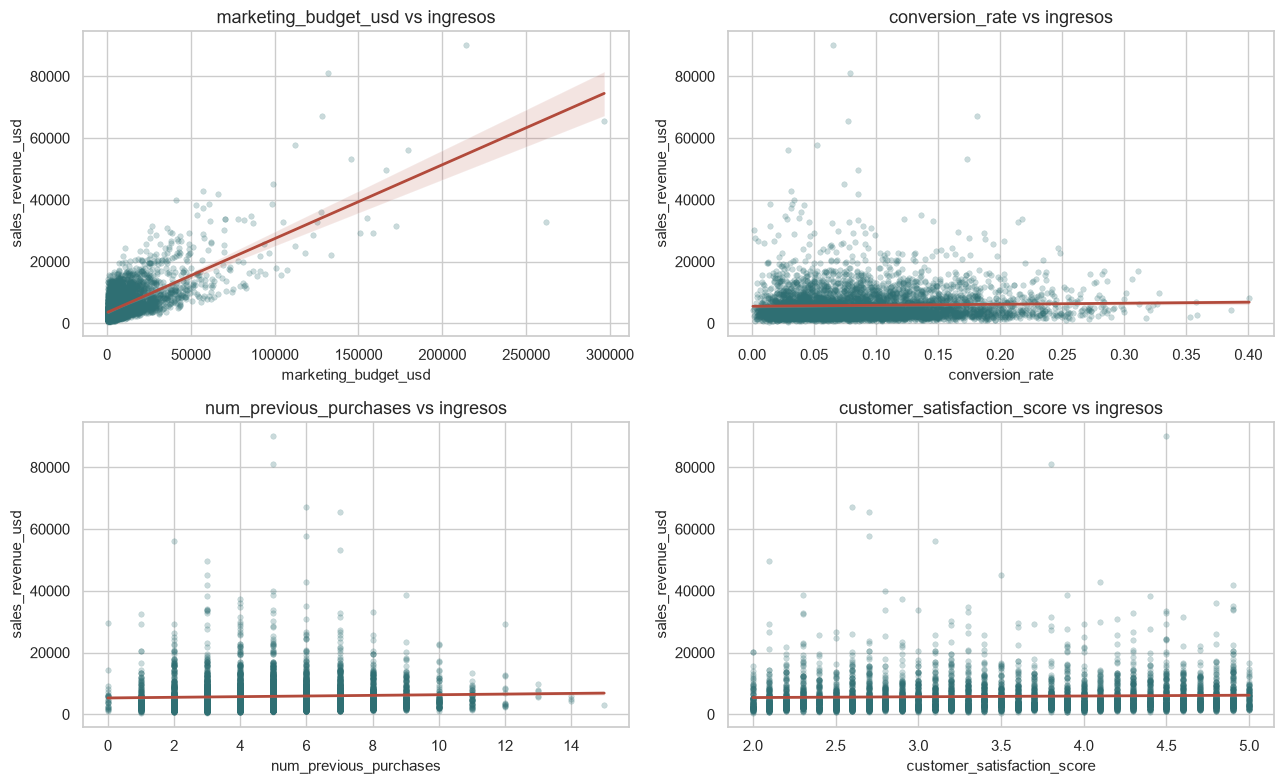

La asociacion lineal mas alta con los ingresos es `marketing_budget_usd` (r = 0.727). `marketing_budget_usd`, `ad_spend_online_usd` y `ad_spend_offline_usd` muestran las correlaciones mas fuertes, pero tambien son variables muy relacionadas entre si.

In [10]:
correlations = df[numeric_cols].corr()[TARGET].drop(TARGET).to_frame("correlacion_con_sales_revenue")
correlations["abs_correlacion"] = correlations["correlacion_con_sales_revenue"].abs()
correlations = correlations.sort_values("abs_correlacion", ascending=False)
display(correlations.round(3))

scatter_vars = ["marketing_budget_usd", "conversion_rate", "num_previous_purchases", "customer_satisfaction_score"]
scatter_df = df.sample(n=min(5000, len(df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()
for ax, col in zip(axes, scatter_vars):
    sns.scatterplot(data=scatter_df, x=col, y=TARGET, ax=ax, alpha=0.25, s=16, color="#2F6F73", edgecolor=None)
    sns.regplot(data=scatter_df, x=col, y=TARGET, ax=ax, scatter=False, color="#B24A3B", line_kws={"linewidth": 2})
    ax.set_title(f"{col} vs ingresos")
    ax.set_ylabel("sales_revenue_usd")
plt.tight_layout()
plt.show()

top_corr = correlations.iloc[0]
display(Markdown(
    f"La asociacion lineal mas alta con los ingresos es `{top_corr.name}` (r = {top_corr['correlacion_con_sales_revenue']:.3f}). "
    "`marketing_budget_usd`, `ad_spend_online_usd` y `ad_spend_offline_usd` muestran las correlaciones mas fuertes, pero tambien son variables muy relacionadas entre si."
))

## 11. Seleccion de variables explicativas

La seleccion no mete automaticamente todas las variables. Se combina sentido empresarial, relacion con Y, linealidad aproximada, calidad de datos y multicolinealidad. En particular, se revisa la redundancia entre presupuesto total y gasto online/offline.

In [11]:
marketing_corr = df[["marketing_budget_usd", "ad_spend_online_usd", "ad_spend_offline_usd", TARGET]].corr()
display(marketing_corr.round(3))

selected_numeric = [
    "marketing_budget_usd", "num_promotions", "discount_percentage",
    "num_sales_representatives", "customer_age", "customer_satisfaction_score",
    "competitor_price_index", "website_traffic", "conversion_rate", "email_open_rate",
    "social_media_followers", "days_since_last_purchase", "num_previous_purchases",
]
selected_categorical = ["customer_segment", "sales_channel", "product_category", "region", "season"]
selected_vars = selected_numeric + selected_categorical

selection_table = pd.DataFrame({"variable": selected_vars, "incluida_modelo_principal": "si"})
selection_table["justificacion"] = "Aporta informacion empresarial y permite controlar el resto de bloques."
selection_table.loc[selection_table["variable"].eq("marketing_budget_usd"), "justificacion"] = "Resume inversion de marketing y evita redundancia con online/offline."
display(selection_table)

display(Markdown(
    "`marketing_budget_usd` esta muy correlacionada con `ad_spend_online_usd` y `ad_spend_offline_usd`. "
    "Para mantener una especificacion interpretable y reducir multicolinealidad, el modelo principal usa el presupuesto total y no incluye simultaneamente sus dos componentes. `id` y `date` quedan excluidas."
))

,marketing_budget_usd,ad_spend_online_usd,ad_spend_offline_usd,sales_revenue_usd
marketing_budget_usd,1.00,0.95,0.93,0.73
ad_spend_online_usd,0.95,1.00,0.89,0.70
ad_spend_offline_usd,0.93,0.89,1.00,0.68
sales_revenue_usd,0.73,0.70,0.68,1.00


,variable,incluida_modelo_principal,justificacion
0,marketing_budget_usd,si,Resume inversion de marketing y evita redundan...
1,num_promotions,si,Aporta informacion empresarial y permite contr...
2,discount_percentage,si,Aporta informacion empresarial y permite contr...
3,num_sales_representatives,si,Aporta informacion empresarial y permite contr...
4,customer_age,si,Aporta informacion empresarial y permite contr...
5,customer_satisfaction_score,si,Aporta informacion empresarial y permite contr...
6,competitor_price_index,si,Aporta informacion empresarial y permite contr...
7,website_traffic,si,Aporta informacion empresarial y permite contr...
8,conversion_rate,si,Aporta informacion empresarial y permite contr...
9,email_open_rate,si,Aporta informacion empresarial y permite contr...


`marketing_budget_usd` esta muy correlacionada con `ad_spend_online_usd` y `ad_spend_offline_usd`. Para mantener una especificacion interpretable y reducir multicolinealidad, el modelo principal usa el presupuesto total y no incluye simultaneamente sus dos componentes. `id` y `date` quedan excluidas.

## 12. Preparacion para regresion

Se define `y = sales_revenue_usd` y las `X` seleccionadas. Los nulos numericos se imputan con la mediana, resistente a outliers. Las variables categoricas se convierten a dummies con `drop_first=True`: con k categorias se crean k-1 dummies y una categoria queda como referencia.

In [12]:
model_df = df[[TARGET] + selected_vars].copy()
numeric_medians = model_df[selected_numeric].median()
model_df[selected_numeric] = model_df[selected_numeric].fillna(numeric_medians)
model_df = model_df.dropna(subset=[TARGET] + selected_categorical)

y = model_df[TARGET]
X_raw = model_df[selected_vars]
X = pd.get_dummies(X_raw, columns=selected_categorical, drop_first=True, dtype=float)

print(f"Observaciones para modelado: {len(model_df):,}")
print(f"Variables explicativas tras dummies: {X.shape[1]:,}")
display(pd.DataFrame({"variable_modelo": X.columns}))

Observaciones para modelado: 60,000
Variables explicativas tras dummies: 33


,variable_modelo
0,marketing_budget_usd
1,num_promotions
2,discount_percentage
3,num_sales_representatives
4,customer_age
5,customer_satisfaction_score
6,competitor_price_index
7,website_traffic
8,conversion_rate
9,email_open_rate


## 13. Separacion entrenamiento/test

La regresion se ajusta solo con el 80% de entrenamiento. El 20% de test se reserva para evaluar capacidad predictiva con datos no usados en el ajuste.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test, has_constant="add")

print(f"Train: {X_train.shape[0]:,} observaciones ({X_train.shape[0] / len(X):.0%})")
print(f"Test: {X_test.shape[0]:,} observaciones ({X_test.shape[0] / len(X):.0%})")

Train: 48,000 observaciones (80%)
Test: 12,000 observaciones (20%)


## 14. Regresion lineal multiple

El modelo se ajusta sobre training con Statsmodels para obtener coeficientes, errores estandar, p-valores, R2 y R2 ajustado. La interpretacion debe ser ceteris paribus: manteniendo constantes las demas variables.

In [14]:
modelo = sm.OLS(y_train, X_train_sm).fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      sales_revenue_usd   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     7279.
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:01:53   Log-Likelihood:            -4.4159e+05
No. Observations:               48000   AIC:                         8.832e+05
Df Residuals:                   47966   BIC:                         8.835e+05
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                             4178.1160    113.241     36.896      0.000    3956.162    4400.070
marketing_budget_usd                 0.2448      0.001    392.227      0.000       0.244       0.246
num_promotions                      68.3977      3.805     17.976      0.000      60.940      75.855
discount_percentage                -14.6198      0.967    -15.124      0.000     -16.514     -12.725
num_sales_representatives            0.7204      0.771      0.934      0.350      -0.791       2.232
customer_age                        -0.9252      0.664     -1.393      0.164      -2.227       0.377
customer_satisfaction_score        257.7543     12.816     20.112      0.000     232.636     282.873
competitor_price_index            -782.9470     63.297    -12.369      0.000    -907.010    -658.884
website_traffic                      0.0017      0.000     10.083      0.000       0.001       0.002
conversion_rate                   4059.1991    182.082     22.293      0.000    3702.317    4416.081
email_open_rate                    -66.5966     98.684     -0.675      0.500    -260.018     126.825
social_media_followers              -0.0001   9.13e-05     -1.267      0.205      -0.000    6.33e-05
days_since_last_purchase            -0.6909      0.105     -6.555      0.000      -0.897      -0.484
num_previous_purchases             134.3862      4.892     27.473      0.000     124.799     143.974
customer_segment_New             -7295.8024     34.373   -212.255      0.000   -7363.173   -7228.431
customer_segment_Regular         -5809.3684     32.972   -176.191      0.000   -5873.994   -5744.743
customer_segment_VIP             -1874.5397     39.851    -47.038      0.000   -1952.649   -1796.430
sales_channel_Online              1128.7643     34.379     32.833      0.000    1061.380    1196.148
sales_channel_Retail Store         569.8559     35.549     16.030      0.000     500.179     639.533
sales_channel_Social Media         842.2974     44.734     18.829      0.000     754.617     929.977
sales_channel_Wholesale           1665.3911     37.117     44.869      0.000    1592.642    1738.140
product_category_Cosmetics         277.6844     37.205      7.464      0.000     204.762     350.607
product_category_Electronics      2937.6739     33.834     86.826      0.000    2871.359    3003.989
product_category_Food & Beverage  -344.8557     32.821    -10.507      0.000    -409.185    -280.527
product_category_Home Appliances  1904.8516     35.577     53.541      0.000    1835.119    1974.584
region_Amman                       -10.8102     50.034     -0.216      0.829    -108.877      87.257
region_Cairo                         7.3085     35.625      0.205      0.837     -62.517      77.134
region_Casablanca                  -32.2998     50.03

In [15]:
coef_table = pd.DataFrame({
    "variable": modelo.params.index,
    "coeficiente": modelo.params.values,
    "error_estandar": modelo.bse.values,
    "p_valor": modelo.pvalues.values,
})
coef_table = coef_table[coef_table["variable"] != "const"].copy()
coef_table["significatividad"] = np.select(
    [coef_table["p_valor"] < 0.001, coef_table["p_valor"] < 0.01, coef_table["p_valor"] < 0.05],
    ["***", "**", "*"],
    default="ns",
)
display(coef_table.sort_values("p_valor").round(4))

,variable,coeficiente,error_estandar,p_valor,significatividad
1,marketing_budget_usd,0.24,0.00,0.00,***
14,customer_segment_New,"-7,295.80",34.37,0.00,***
16,customer_segment_VIP,"-1,874.54",39.85,0.00,***
15,customer_segment_Regular,"-5,809.37",32.97,0.00,***
22,product_category_Electronics,"2,937.67",33.83,0.00,***
24,product_category_Home Appliances,"1,904.85",35.58,0.00,***
20,sales_channel_Wholesale,"1,665.39",37.12,0.00,***
33,season_Q4,"2,762.02",31.04,0.00,***
32,season_Q3,"1,113.17",30.93,0.00,***
17,sales_channel_Online,"1,128.76",34.38,0.00,***


## 15. Evaluacion obligatoria: R2, MAE y RMSE

Se predice sobre test y se calculan las metricas solicitadas por el profesor. No se debe confundir el R2 de entrenamiento con el R2 de test.

In [16]:
y_pred_test = modelo.predict(X_test_sm)

r2_train = modelo.rsquared
r2_adj_train = modelo.rsquared_adj
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

evaluation_table = pd.DataFrame({
    "Metrica": ["R2 entrenamiento", "R2 ajustado entrenamiento", "R2 test", "MAE test", "RMSE test"],
    "Resultado": [r2_train, r2_adj_train, r2_test, mae_test, rmse_test],
})
display(evaluation_table.round(3))

display(Markdown(
    f"El modelo alcanza un **R2 de test de {r2_test:.3f}**, por lo que explica una parte alta de la variabilidad de ingresos en observaciones no usadas para ajustar. "
    f"El **MAE** indica que las predicciones se desvian en promedio aproximadamente **{usd(mae_test)}** respecto a los ingresos reales. "
    f"El **RMSE** es **{usd(rmse_test)}** y penaliza mas los errores grandes. La cercania entre R2 de entrenamiento ({r2_train:.3f}) y R2 de test ({r2_test:.3f}) no sugiere un sobreajuste fuerte."
))

,Metrica,Resultado
0,R2 entrenamiento,0.83
1,R2 ajustado entrenamiento,0.83
2,R2 test,0.83
3,MAE test,"1,247.23"
4,RMSE test,"2,361.05"


El modelo alcanza un **R2 de test de 0.831**, por lo que explica una parte alta de la variabilidad de ingresos en observaciones no usadas para ajustar. El **MAE** indica que las predicciones se desvian en promedio aproximadamente **1,247.23 USD** respecto a los ingresos reales. El **RMSE** es **2,361.05 USD** y penaliza mas los errores grandes. La cercania entre R2 de entrenamiento (0.834) y R2 de test (0.831) no sugiere un sobreajuste fuerte.

## 16. Interpretacion de coeficientes seleccionados

No se interpretan todos los coeficientes. Se seleccionan variables significativas, relevantes para negocio y faciles de explicar. La constante no se interpreta.

In [17]:
priority_terms = [
    "marketing_budget_usd", "conversion_rate", "customer_satisfaction_score",
    "num_previous_purchases", "num_promotions", "discount_percentage",
    "customer_segment_New", "customer_segment_Regular",
    "product_category_Electronics", "season_Q4", "sales_channel_Wholesale",
]
interpretation_table = coef_table[coef_table["variable"].isin(priority_terms)].copy()
interpretation_table = interpretation_table.sort_values("p_valor").head(8)
display(interpretation_table.round(4))

lines = []
dummy_prefixes = ["customer_segment", "sales_channel", "product_category", "region", "season"]
for _, row in interpretation_table.iterrows():
    var = row["variable"]
    beta = row["coeficiente"]
    if any(var.startswith(prefix) for prefix in dummy_prefixes):
        lines.append(f"- `{var}`: manteniendo constantes las demas variables, pertenecer a esta categoria se asocia con una diferencia media de **{usd(beta)}** respecto a la categoria de referencia.")
    elif var == "conversion_rate":
        lines.append(f"- `{var}`: un aumento de 1 unidad en la tasa de conversion se asocia con **{usd(beta)}** mas de ingresos; un aumento de 0,01 se asocia aproximadamente con **{usd(beta * 0.01)}**.")
    else:
        lines.append(f"- `{var}`: manteniendo constantes las demas variables, un aumento de una unidad se asocia con **{usd(beta)}** de diferencia media en ingresos.")
display(Markdown("\n".join(lines)))

,variable,coeficiente,error_estandar,p_valor,significatividad
1,marketing_budget_usd,0.24,0.00,0.00,***
15,customer_segment_Regular,"-5,809.37",32.97,0.00,***
14,customer_segment_New,"-7,295.80",34.37,0.00,***
20,sales_channel_Wholesale,"1,665.39",37.12,0.00,***
22,product_category_Electronics,"2,937.67",33.83,0.00,***
33,season_Q4,"2,762.02",31.04,0.00,***
13,num_previous_purchases,134.39,4.89,0.00,***
9,conversion_rate,"4,059.20",182.08,0.00,***


- `marketing_budget_usd`: manteniendo constantes las demas variables, un aumento de una unidad se asocia con **0.24 USD** de diferencia media en ingresos.
- `customer_segment_Regular`: manteniendo constantes las demas variables, pertenecer a esta categoria se asocia con una diferencia media de **-5,809.37 USD** respecto a la categoria de referencia.
- `customer_segment_New`: manteniendo constantes las demas variables, pertenecer a esta categoria se asocia con una diferencia media de **-7,295.80 USD** respecto a la categoria de referencia.
- `sales_channel_Wholesale`: manteniendo constantes las demas variables, pertenecer a esta categoria se asocia con una diferencia media de **1,665.39 USD** respecto a la categoria de referencia.
- `product_category_Electronics`: manteniendo constantes las demas variables, pertenecer a esta categoria se asocia con una diferencia media de **2,937.67 USD** respecto a la categoria de referencia.
- `season_Q4`: manteniendo constantes las demas variables, pertenecer a esta categoria se asocia con una diferencia media de **2,762.02 USD** respecto a la categoria de referencia.
- `num_previous_purchases`: manteniendo constantes las demas variables, un aumento de una unidad se asocia con **134.39 USD** de diferencia media en ingresos.
- `conversion_rate`: un aumento de 1 unidad en la tasa de conversion se asocia con **4,059.20 USD** mas de ingresos; un aumento de 0,01 se asocia aproximadamente con **40.59 USD**.

## 17. VIF: multicolinealidad

Se calcula el factor de inflacion de la varianza sobre las X del modelo. Como referencia: VIF < 5 suele ser correcto, 5-10 requiere revision y > 10 indica un problema serio.

In [18]:
vif_table = pd.DataFrame({"variable": X_train.columns})
vif_table["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_table = vif_table.sort_values("VIF", ascending=False)
display(vif_table.round(3))

max_vif = vif_table["VIF"].max()
max_vif_var = vif_table.iloc[0]["variable"]
if max_vif < 5:
    msg = f"El VIF maximo es **{max_vif:.2f}** en `{max_vif_var}`, por debajo de 5. No aparece multicolinealidad seria en el modelo principal."
elif max_vif < 10:
    msg = f"El VIF maximo es **{max_vif:.2f}** en `{max_vif_var}`. Hay variables a revisar, aunque no se supera el umbral de problema serio."
else:
    msg = f"El VIF maximo es **{max_vif:.2f}** en `{max_vif_var}`, lo que sugiere multicolinealidad seria. Seria necesario replantear variables redundantes."
display(Markdown(msg))

,variable,VIF
14,customer_segment_Regular,2.18
13,customer_segment_New,2.08
16,sales_channel_Online,2.08
25,region_Cairo,1.99
17,sales_channel_Retail Store,1.98
29,region_Riyadh,1.86
19,sales_channel_Wholesale,1.85
27,region_Dubai,1.80
22,product_category_Food & Beverage,1.69
15,customer_segment_VIP,1.69


El VIF maximo es **2.18** en `customer_segment_Regular`, por debajo de 5. No aparece multicolinealidad seria en el modelo principal.

## 18. Diagnostico de residuos

Se revisan residuos frente a valores predichos, histograma y Q-Q plot. El objetivo es detectar patrones, forma de embudo, valores extremos y normalidad aproximada. Con muestras grandes no se exige normalidad perfecta.

,resultado
media_residuos,0.00
desv_tipica_residuos,"2,394.18"
asimetria_residuos,4.24
curtosis_residuos,140.55


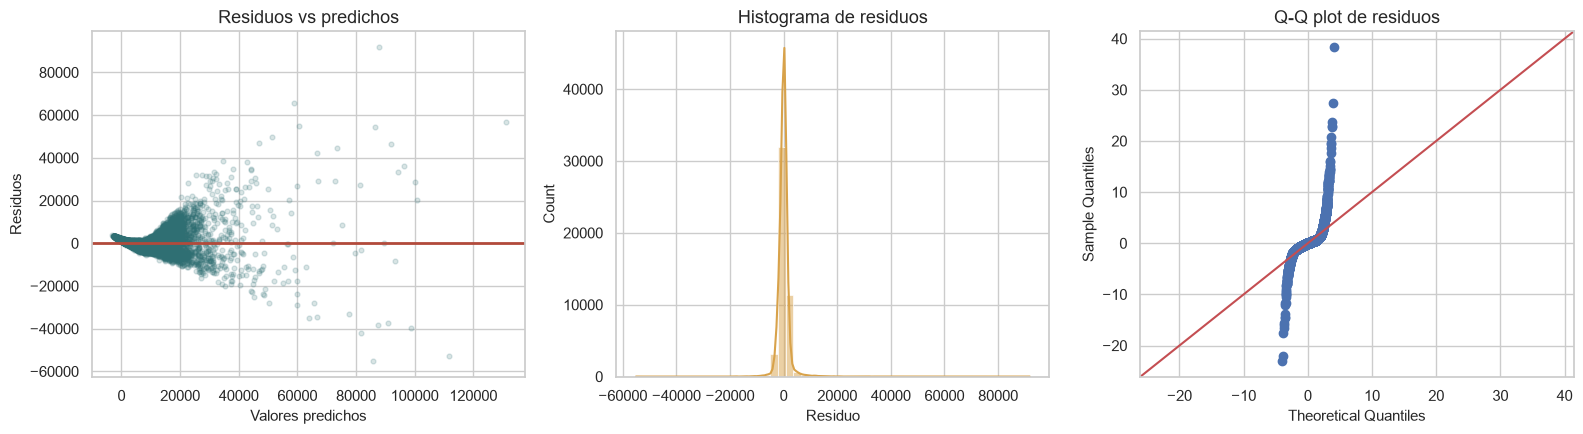

Los residuos tienen media cercana a cero (0.00). La asimetria (4.24) y la curtosis (140.55) sugieren que no siguen perfectamente una distribucion normal, especialmente por errores grandes asociados a ingresos extremos.

In [19]:
fitted_train = modelo.fittedvalues
residuals_train = modelo.resid

resid_stats = pd.Series({
    "media_residuos": residuals_train.mean(),
    "desv_tipica_residuos": residuals_train.std(),
    "asimetria_residuos": stats.skew(residuals_train),
    "curtosis_residuos": stats.kurtosis(residuals_train),
})
display(resid_stats.to_frame("resultado").round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(fitted_train, residuals_train, alpha=0.18, s=12, color="#2F6F73")
axes[0].axhline(0, color="#B24A3B", linewidth=2)
axes[0].set_title("Residuos vs predichos")
axes[0].set_xlabel("Valores predichos")
axes[0].set_ylabel("Residuos")
sns.histplot(residuals_train, bins=50, kde=True, ax=axes[1], color="#D8A24A")
axes[1].set_title("Histograma de residuos")
axes[1].set_xlabel("Residuo")
sm.qqplot(residuals_train, line="45", fit=True, ax=axes[2])
axes[2].set_title("Q-Q plot de residuos")
plt.tight_layout()
plt.show()

display(Markdown(
    f"Los residuos tienen media cercana a cero ({resid_stats['media_residuos']:.2f}). "
    f"La asimetria ({resid_stats['asimetria_residuos']:.2f}) y la curtosis ({resid_stats['curtosis_residuos']:.2f}) sugieren que no siguen perfectamente una distribucion normal, especialmente por errores grandes asociados a ingresos extremos."
))

## 19. Heterocedasticidad: test de White

Se aplica el test de White sobre una muestra reproducible del conjunto de entrenamiento para mantener el coste computacional bajo. H0: homocedasticidad. Si p < 0,05 hay evidencia de heterocedasticidad. Si aparece, se calculan errores estandar robustos HC3.

In [20]:
white_n = min(8000, len(X_train_sm))
white_idx = X_train_sm.sample(n=white_n, random_state=RANDOM_STATE).index
white_stat = het_white(residuals_train.loc[white_idx], X_train_sm.loc[white_idx])
white_table = pd.DataFrame({
    "estadistico": ["LM", "LM p-valor", "F", "F p-valor"],
    "resultado": white_stat,
})
display(white_table.round(6))

modelo_robusto = modelo.get_robustcov_results(cov_type="HC3")
robust_table = pd.DataFrame({
    "variable": modelo.params.index,
    "coeficiente": modelo.params.values,
    "error_estandar_OLS": modelo.bse.values,
    "p_valor_OLS": modelo.pvalues.values,
    "error_estandar_HC3": modelo_robusto.bse,
    "p_valor_HC3": modelo_robusto.pvalues,
})
robust_table = robust_table[robust_table["variable"] != "const"]
display(robust_table.sort_values("p_valor_HC3").head(15).round(4))

white_p = white_stat[1]
if white_p < 0.05:
    msg = f"El p-valor del test de White es **{white_p:.6f}**, por debajo de 0,05. Hay evidencia de heterocedasticidad. Los coeficientes no cambian al usar HC3, pero si cambian los errores estandar y potencialmente los p-valores."
else:
    msg = f"El p-valor del test de White es **{white_p:.6f}**, por encima de 0,05. No se detecta evidencia estadistica clara de heterocedasticidad con esta prueba."
display(Markdown(msg))

,estadistico,resultado
0,LM,"6,075.98"
1,LM p-valor,0.00
2,F,48.93
3,F p-valor,0.00


,variable,coeficiente,error_estandar_OLS,p_valor_OLS,error_estandar_HC3,p_valor_HC3
1,marketing_budget_usd,0.24,0.00,0.00,0.01,0.00
15,customer_segment_Regular,"-5,809.37",32.97,0.00,47.39,0.00
14,customer_segment_New,"-7,295.80",34.37,0.00,49.66,0.00
20,sales_channel_Wholesale,"1,665.39",37.12,0.00,38.66,0.00
22,product_category_Electronics,"2,937.67",33.83,0.00,35.71,0.00
24,product_category_Home Appliances,"1,904.85",35.58,0.00,34.07,0.00
33,season_Q4,"2,762.02",31.04,0.00,34.06,0.00
32,season_Q3,"1,113.17",30.93,0.00,29.45,0.00
17,sales_channel_Online,"1,128.76",34.38,0.00,34.91,0.00
16,customer_segment_VIP,"-1,874.54",39.85,0.00,58.93,0.00


El p-valor del test de White es **0.000000**, por debajo de 0,05. Hay evidencia de heterocedasticidad. Los coeficientes no cambian al usar HC3, pero si cambian los errores estandar y potencialmente los p-valores.

## 20. Modelo logaritmico: revision breve

El logaritmo solo se prueba porque la variable objetivo tiene cola derecha y los residuos presentan valores extremos. No se convierte en el modelo principal salvo que mejore claramente interpretacion y estabilidad.

In [21]:
y_log = np.log(y)
y_log_train = y_log.loc[y_train.index]
y_log_test = y_log.loc[y_test.index]
modelo_log = sm.OLS(y_log_train, X_train_sm).fit()
y_log_pred = modelo_log.predict(X_test_sm)

log_eval = pd.DataFrame({
    "modelo": ["niveles", "log(y)"],
    "R2_train": [modelo.rsquared, modelo_log.rsquared],
    "R2_test_escala_modelo": [r2_test, r2_score(y_log_test, y_log_pred)],
    "asimetria_residuos_train": [stats.skew(modelo.resid), stats.skew(modelo_log.resid)],
    "curtosis_residuos_train": [stats.kurtosis(modelo.resid), stats.kurtosis(modelo_log.resid)],
})
display(log_eval.round(4))

display(Markdown(
    "El modelo logaritmico mejora algunos diagnosticos de forma, pero cambia la interpretacion de los coeficientes. "
    "Como el requisito central es una regresion lineal multiple interpretable en ingresos USD y el modelo en niveles ya presenta buen desempeno predictivo, se mantiene el modelo principal en niveles y se deja el logaritmo solo como comprobacion."
))

,modelo,R2_train,R2_test_escala_modelo,asimetria_residuos_train,curtosis_residuos_train
0,niveles,0.83,0.83,4.24,140.55
1,log(y),0.87,0.88,-3.42,65.38


El modelo logaritmico mejora algunos diagnosticos de forma, pero cambia la interpretacion de los coeficientes. Como el requisito central es una regresion lineal multiple interpretable en ingresos USD y el modelo en niveles ya presenta buen desempeno predictivo, se mantiene el modelo principal en niveles y se deja el logaritmo solo como comprobacion.

## 21. Conclusiones

Los hallazgos responden a la pregunta de investigacion usando lenguaje de asociacion, no causalidad.

In [22]:
hallazgos = [
    f"El bloque de marketing destaca: `marketing_budget_usd` es la variable numerica con mayor correlacion con ingresos (r = {correlations.loc['marketing_budget_usd', 'correlacion_con_sales_revenue']:.3f}) y mantiene una asociacion positiva en la regresion multiple.",
    "El contexto comercial tambien importa: categorias como `product_category_Electronics` y temporadas como `season_Q4` muestran diferencias medias positivas frente a sus categorias de referencia, manteniendo constantes las demas variables.",
    "El comportamiento del cliente aporta informacion: `num_previous_purchases` y `customer_satisfaction_score` se asocian positivamente con los ingresos en el modelo principal.",
    "El engagement digital aparece sobre todo mediante `conversion_rate`, que se asocia positivamente con mayores ingresos; otros indicadores digitales tienen menor peso lineal directo.",
    f"El modelo tiene buen desempeno predictivo para un enfoque lineal: R2 test = {r2_test:.3f}, MAE = {usd(mae_test)} y RMSE = {usd(rmse_test)}.",
]
display(Markdown("\n".join([f"- {h}" for h in hallazgos])))

- El bloque de marketing destaca: `marketing_budget_usd` es la variable numerica con mayor correlacion con ingresos (r = 0.727) y mantiene una asociacion positiva en la regresion multiple.
- El contexto comercial tambien importa: categorias como `product_category_Electronics` y temporadas como `season_Q4` muestran diferencias medias positivas frente a sus categorias de referencia, manteniendo constantes las demas variables.
- El comportamiento del cliente aporta informacion: `num_previous_purchases` y `customer_satisfaction_score` se asocian positivamente con los ingresos en el modelo principal.
- El engagement digital aparece sobre todo mediante `conversion_rate`, que se asocia positivamente con mayores ingresos; otros indicadores digitales tienen menor peso lineal directo.
- El modelo tiene buen desempeno predictivo para un enfoque lineal: R2 test = 0.831, MAE = 1,247.23 USD y RMSE = 2,361.05 USD.

## 22. Limitaciones

- El dataset es sintetico, por lo que los resultados no deben generalizarse automaticamente a una empresa real.
- El estudio es observacional: asociacion no equivale a causalidad.
- Pueden existir variables omitidas que tambien esten asociadas con los ingresos.
- La regresion lineal multiple captura principalmente relaciones lineales y efectos medios.
- Hay outliers e indicios diagnosticos que recomiendan prudencia al interpretar errores y significatividad.
- Los resultados son especificos de esta muestra y de las variables disponibles.

## 23. Recomendaciones empresariales

- Se recomienda considerar el presupuesto de marketing como variable prioritaria de seguimiento, porque muestra una asociacion fuerte y positiva con ingresos.
- Los resultados apuntan a revisar estrategias diferenciadas por segmento, canal, categoria y temporada, especialmente donde las diferencias medias son mayores.
- Se sugiere monitorizar `conversion_rate`, satisfaccion y compras previas como indicadores utiles para anticipar ingresos, siempre junto con controles comerciales.
- Antes de tomar decisiones causales, convendria complementar este analisis con disenos experimentales o datos longitudinales mas controlados.

# Seleccion para el informe final

## IMPRESCINDIBLES

### 1. Objetivo y datos - 0,5 pagina

- Pregunta de investigacion.
- Dataset, periodo observado y tamano.
- Variable objetivo `sales_revenue_usd`.
- Variables explicativas organizadas en cuatro bloques.

### 2. Descriptiva y outliers - 1 pagina

- Estadisticos clave de `sales_revenue_usd`.
- Histograma o boxplot de ingresos.
- Nulos principales y decision de imputacion para regresion.
- Tabla resumida de outliers IQR y decision de conservarlos inicialmente.

### 3. Relaciones - 1 pagina

- Tabla de correlaciones con Y.
- 1-2 scatter plots, especialmente presupuesto de marketing y conversion.
- Diferencias por grupos mas relevantes: segmento, canal, categoria o temporada.

### 4. Regresion y evaluacion - 2 paginas

- Definicion de Y y X seleccionadas.
- Justificacion de usar `marketing_budget_usd` y no simultaneamente online/offline.
- R2 y R2 ajustado de entrenamiento.
- R2 test, MAE y RMSE.
- 5-8 coeficientes relevantes con interpretacion ceteris paribus.
- VIF resumido.
- Diagnostico de residuos y White muy resumidos.

### 5. Conclusiones y limitaciones - 0,5 pagina

- 3-5 hallazgos principales.
- Recomendaciones prudentes.
- Limitaciones: dataset sintetico, estudio observacional, asociacion no causalidad, variables omitidas y linealidad.

## SOLO NOTEBOOK

- Tablas completas de frecuencias categoricas.
- Tabla descriptiva numerica completa.
- Summary completo de Statsmodels.
- Tabla completa de coeficientes.
- VIF completo.
- Diagnosticos graficos ampliados.
- Comprobacion breve del modelo logaritmico.